## **2. Análisis estadístico**

In [ ]:
demograficas = [
    "sexo",                    # M/F
    "edad_años",               # Edad numérica
    "ciclo_vital",             # Etapa de vida
    "grupo_etnico",            # Grupo étnico declarado
    "regimen_salud"            # Régimen (contributivo, subsidiado, etc.)
]

    # Variables del evento epidemiológico
evento = [
    "evento",                  # Clásico, grave
    "tipo_de_caso",               # Confirmado, probable, descartado
    "hospitalizacion",         # Sí/No
    "desenlace"                # Recuperado, fallecido, etc.
]

    # Variables de temporalidad
temporalidad = [
    "año",                     # Año del evento
    "semana",                  # Semana epidemiológica
    "periodo",                 # Periodo (cada 4 semanas)
    "fecha_inicio_sintomas",   # Inicio de síntomas
    "fecha_consulta",          # Fecha de consulta
    "fecha_hospitalizacion",   # Fecha de hospitalización
    "fecha_notificacion",      # Fecha de notificación
    "fecha_nacimiento"         # Fecha de nacimiento
]

    # Variables espaciales
espacial = [
    "municipio",                # Municipio de ocurrencia
    "area",                    # Urbana o rural
]

### **Pruebas de independencia de variables categóricas**

In [ ]:
# [Test] Prueba de Chi-Cuadrado
def matriz_pvalores(df, variables, alpha=0.05):
    matriz = pd.DataFrame(index=variables, columns=variables)
    for var1 in variables:
        for var2 in variables:
            if var1 == var2:
                matriz.loc[var1, var2] = "-"
            else:
                tabla = pd.crosstab(df[var1], df[var2])
                if tabla.shape[0] > 1 and tabla.shape[1] > 1:
                    chi2, p, dof, exp = chi2_contingency(tabla)
                    matriz.loc[var1, var2] = round(p, 4)
                else:
                    matriz.loc[var1, var2] = None
    return matriz

In [ ]:
# [Test] Prueba de Chi-cuadrado por categoría
def chi_por_categoria(df, variable_referencia, variables_comparar, alpha=0.05):
    categorias = df[variable_referencia].dropna().unique()
    resultados = []

    for categoria in categorias:
        fila = {"Categoría": categoria}
        for var in variables_comparar:
            if var == variable_referencia:
                fila[var] = "-"
                continue

            # Grupo A = categoría específica vs resto
            df_temp = df.copy()
            df_temp["grupo_vs_resto"] = df_temp[variable_referencia].apply(
                lambda x: categoria if x == categoria else f"No {categoria}"
            )

            tabla = pd.crosstab(df_temp["grupo_vs_resto"], df_temp[var])
            _, p, _, _ = chi2_contingency(tabla)
            test = "Chi²"

            simb = "★" if p <= alpha else ""
            fila[var] = f"{round(p,4)} {simb}"
        resultados.append(fila)

    return pd.DataFrame(resultados)

### **Variables demográficas**

In [ ]:
demograficas_c = ["sexo", "ciclo_vital","grupo_etnico","regimen_salud"]

In [ ]:
matriz_demo = matriz_pvalores(df[demograficas_c], demograficas_c)
matriz_demo

,sexo,ciclo_vital,grupo_etnico,regimen_salud
sexo,-,0.0,0.2438,0.0
ciclo_vital,0.0,-,0.4876,0.0
grupo_etnico,0.2438,0.4876,-,0.0
regimen_salud,0.0,0.0,0.0,-


La independencia entre variables demográficas, indica que el ciclo_vital y el regimen de salud están significativamente asociados al sexo de los pacientes, es decir, que la distribución de la edad y la afiliación al sistema de salud varía según el sexo. El regimen de salud está fuertemente asociado con todas las demás variables, siendo esta la más dependiente. Estas asociaciones reflejan patrones de desigualdad o segmentación en la población según características demográficas.

In [ ]:
tabla_sexo = chi_por_categoria(df, "sexo", demograficas_c)
tabla_sexo

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Masculino,-,0.0 ★,0.2438,0.0 ★
1,Femenino,-,0.0 ★,0.2438,0.0 ★


In [ ]:
tabla_ciclo = chi_por_categoria(df, "ciclo_vital", demograficas_c)
tabla_ciclo

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Adolescencia,0.0 ★,-,0.7207,0.0 ★
1,Infancia,0.0 ★,-,0.088,0.0005 ★
2,Adulto,0.1157,-,0.5122,0.0 ★
3,Adulto mayor,0.6273,-,0.1002,0.0004 ★
4,Primera infancia,0.4713,-,0.5287,0.195
5,Menor de 1 año,0.5399,-,0.6423,0.0 ★
6,Ancianidad,0.1277,-,0.991,0.0227 ★


In [ ]:
tabla_salud = chi_por_categoria(df, "regimen_salud", demograficas_c)
tabla_salud

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Subsidiado,0.0 ★,0.0 ★,0.0 ★,-
1,Contributivo,0.0052 ★,0.0 ★,0.0 ★,-
2,Especial,0.2593,0.089,0.981,-
3,Excepción,0.0 ★,0.1484,0.0542,-
4,No asegurado,0.789,0.0017 ★,0.0002 ★,-
5,Indeterminado,1.0,0.0251 ★,0.9738,-


Para cada categoría dentro de las variables se destaca las etapas de vida no se distribuyen igual entre femeninas y masculinos, y el tipo de afiliación al sistema de salud varía entre sexos. 

En casi todas las etapas de vida, el régimen de salud varía notablemente. En la adolescencia y la infancia, la proporción de hombres y mujeres varía.

El régimen de salud esta fuertemente asociado a las demás variables demográficas, con diferencias marcadas para la población subsidiada y contributiva. 

In [ ]:
categoricas = ["sexo", "ciclo_vital","grupo_etnico","regimen_salud", 
                "tipo_de_caso", "hospitalizacion","desenlace"]
tabla_evento = chi_por_categoria(df, "evento", demograficas_c)
tabla_evento

,Categoría,sexo,ciclo_vital,grupo_etnico,regimen_salud
0,Clasico,1.0,0.0003 ★,0.402,0.0 ★
1,Grave,1.0,0.0003 ★,0.402,0.0 ★


La prueba de Chi-Cuadrado de independencia entre el evento de dengue y las variables demográficas muestra que ambos casos de evento están significativamente relacionados a la edad y al régimen de salud.

In [ ]:
matriz_eve= matriz_pvalores(df[evento], evento)
matriz_eve

,evento,tipo_de_caso,hospitalizacion,desenlace
evento,-,0.393,0.0,0.0
tipo_de_caso,0.393,-,0.0,0.756
hospitalizacion,0.0,0.0,-,0.756
desenlace,0.0,0.756,0.756,-


Con respecto a las variables relacionadas con el evento epidemiológico, se observa que la hospitalización y desenlace están significativamente asociados con el evento. Además, la hospitalización y el tipo de caso tienen una asociación significativa, lo que sugiere que los casos confirmados o probables tienen diferente propensión a ser hospitalizados. 

### **Análisis bivariado: Variables de evento según demografía**

#### *Hospitalización de pacientes*

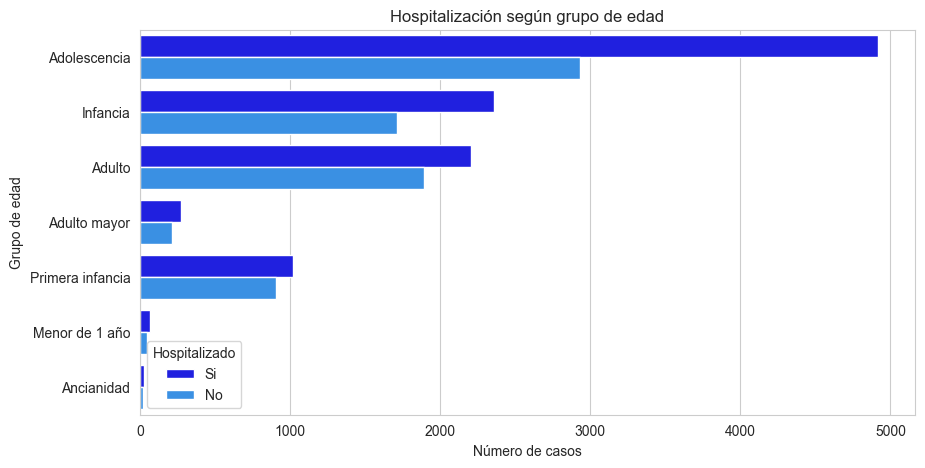

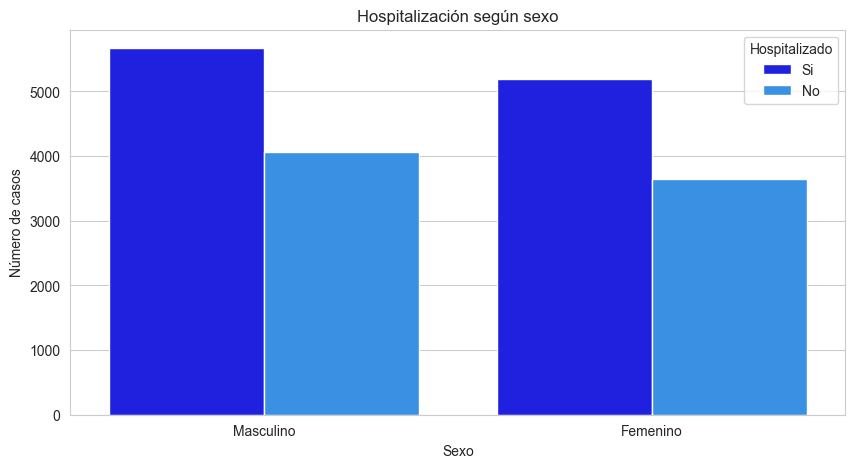

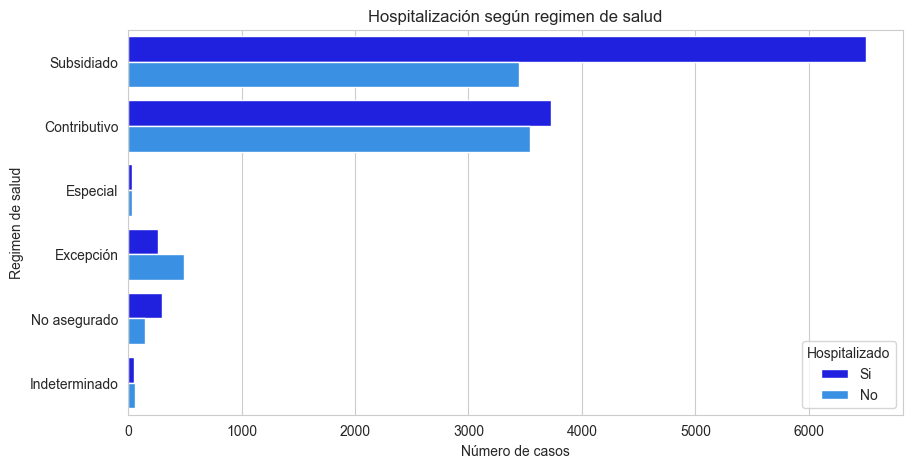

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="ciclo_vital", hue="hospitalizacion", palette=[ 'blue','dodgerblue'] )
plt.title("Hospitalización según grupo de edad")
plt.ylabel("Grupo de edad")
plt.xlabel("Número de casos")
plt.legend(title="Hospitalizado")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="sexo", hue="hospitalizacion", palette=[ 'blue','dodgerblue'] )
plt.title("Hospitalización según sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.legend(title="Hospitalizado")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, y="regimen_salud", hue="hospitalizacion", palette=[ 'blue','dodgerblue'] )
plt.title("Hospitalización según regimen de salud")
plt.ylabel("Regimen de salud")
plt.xlabel("Número de casos")
plt.legend(title="Hospitalizado")
plt.show()

#### *Tipo de caso*

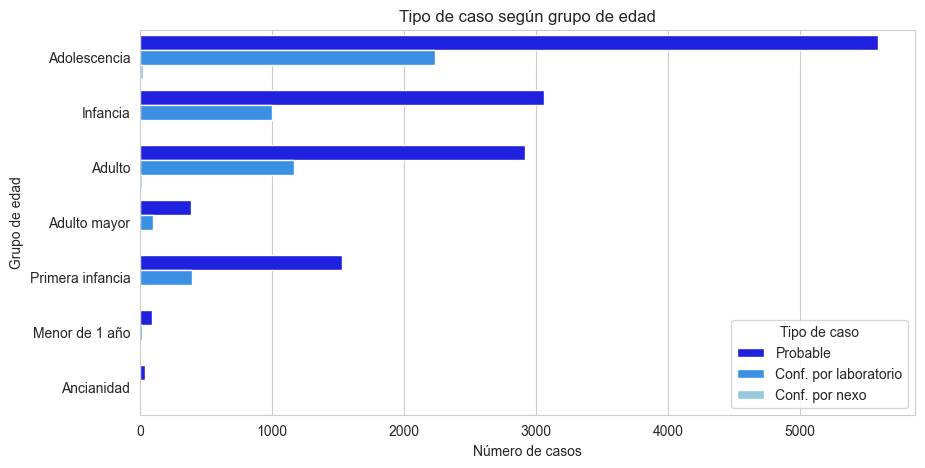

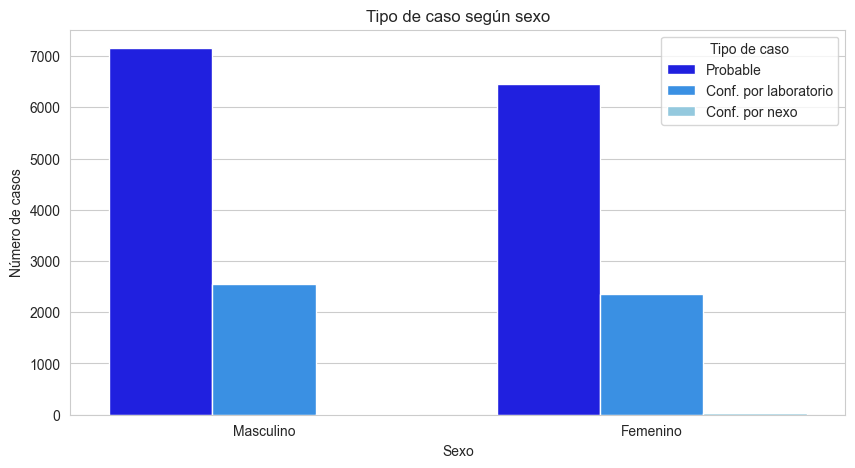

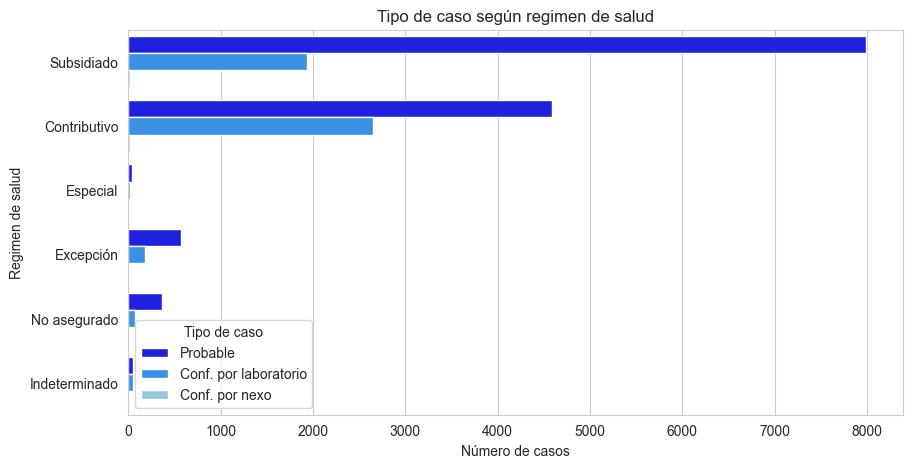

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y="ciclo_vital", hue="tipo_de_caso", palette=[ 'blue','dodgerblue','skyblue'] )
plt.title("Tipo de caso según grupo de edad")
plt.ylabel("Grupo de edad")
plt.xlabel("Número de casos")
plt.legend(title="Tipo de caso")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="sexo", hue="tipo_de_caso", palette=[ 'blue','dodgerblue','skyblue'] )
plt.title("Tipo de caso según sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.legend(title="Tipo de caso")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, y="regimen_salud", hue="tipo_de_caso", palette=[ 'blue','dodgerblue','skyblue'] )
plt.title("Tipo de caso según regimen de salud")
plt.ylabel("Regimen de salud")
plt.xlabel("Número de casos")
plt.legend(title="Tipo de caso")
plt.show()

#### *Desenlace*

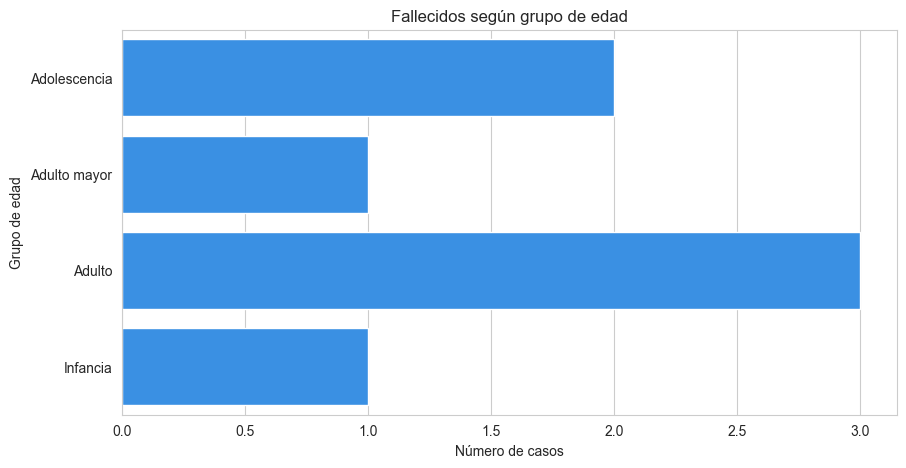

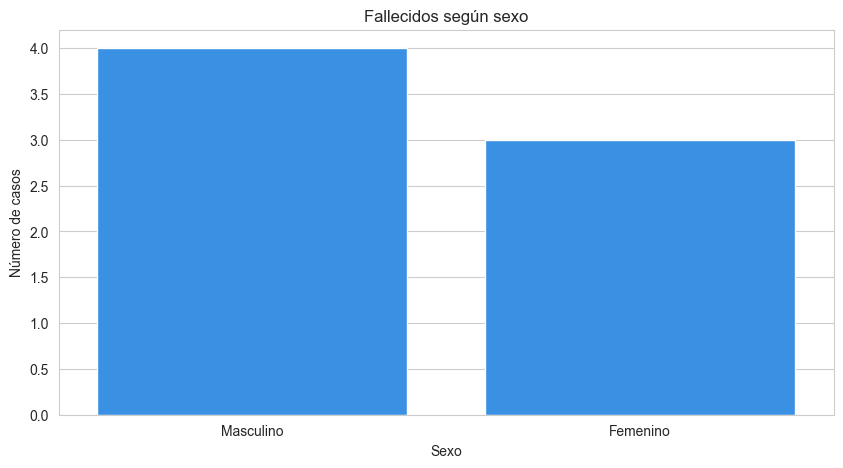

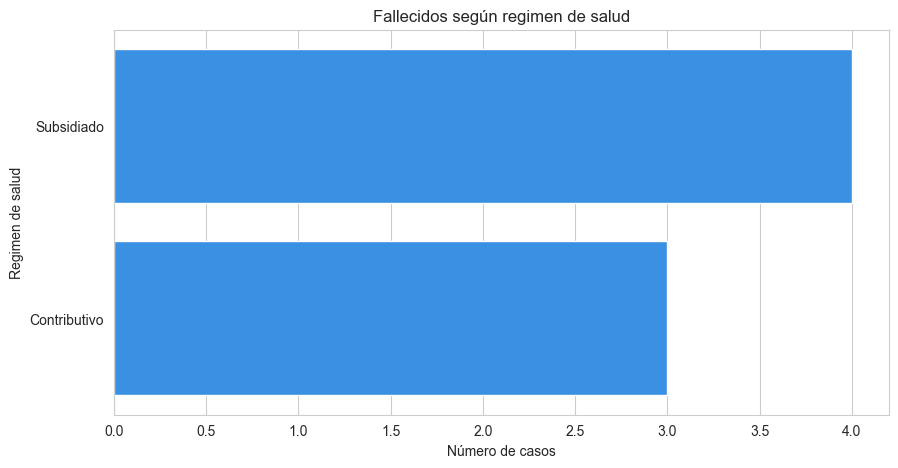

In [ ]:
df_fallecidos = df[df["desenlace"] == "Fallecido"]

plt.figure(figsize=(10,5))
sns.countplot(data=df_fallecidos, y="ciclo_vital", color='dodgerblue')
plt.title("Fallecidos según grupo de edad")
plt.ylabel("Grupo de edad")
plt.xlabel("Número de casos")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df_fallecidos, x="sexo", color='dodgerblue')
plt.title("Fallecidos según sexo")
plt.xlabel("Sexo")
plt.ylabel("Número de casos")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df_fallecidos, y="regimen_salud", color='dodgerblue')
plt.title("Fallecidos según regimen de salud")
plt.ylabel("Regimen de salud")
plt.xlabel("Número de casos")
plt.show()

### **Temporalidad de casos**

In [ ]:
# [Test] Shapiro para normalidad
stat, p = shapiro(semanas['total_casos'])
print(f"Estadístico={stat:.3f}, p-valor={p:.4f}")


Estadístico=0.849, p-valor=0.0000


Los casos de dengue por semana, de acuerdo a la prueba shapiro, no siguen una distribución normal.

In [ ]:
# [Test] Kruskall Wallys para correspondencia
def comparar_casos_por_año(df, num_var='casos', cat_var='año', alpha=0.05):

    grupos = [df[df[cat_var]==g][num_var] for g in df[cat_var].unique()]
    
    # Kruskal-Wallis
    stat, p = kruskal(*grupos)
    kruskal_res = pd.DataFrame({
        'Estadístico': [stat],
        'p-valor': [p],
        'Significativo': ["★" if p <= alpha else ""]
    })
    
    # Post-hoc Dunn (solo si hay más de 2 grupos)
    if len(df[cat_var].unique()) > 2:
        posthoc = sp.posthoc_dunn(df, val_col=num_var, group_col=cat_var, p_adjust='bonferroni')
    else:
        posthoc = None
    
    return {'kruskal': kruskal_res, 'posthoc': posthoc}


resultados = comparar_casos_por_año(semanas, num_var='total_casos', cat_var='año')

print("Kruskal-Wallis:")
resultados['kruskal']

Kruskal-Wallis:


,Estadístico,p-valor,Significativo
0,171.980016,1.709937e-34,★


In [ ]:
print("\nDunn post-hoc (p-valores corregidos Bonferroni):")
resultados['posthoc']


Dunn post-hoc (p-valores corregidos Bonferroni):


,2017,2018,2019,2020,2021,2022,2023
2017,1.000000e+00,1.696668e-04,6.715088e-07,2.942825e-01,8.032218e-08,3.512154e-18,8.487212e-28
2018,1.696668e-04,1.000000e+00,1.000000e+00,8.951510e-01,1.000000e+00,1.025256e-04,3.378912e-10
2019,6.715088e-07,1.000000e+00,1.000000e+00,4.069308e-02,1.000000e+00,9.675433e-03,2.989544e-07
2020,2.942825e-01,8.951510e-01,4.069308e-02,1.000000e+00,1.074953e-02,7.602006e-10,2.949031e-17
2021,8.032218e-08,1.000000e+00,1.000000e+00,1.074953e-02,1.000000e+00,4.101027e-02,3.113899e-06
2022,3.512154e-18,1.025256e-04,9.675433e-03,7.602006e-10,4.101027e-02,1.000000e+00,6.334551e-01
2023,8.487212e-28,3.378912e-10,2.989544e-07,2.949031e-17,3.113899e-06,6.334551e-01,1.000000e+00


La comparación del número de casos por semana entre los años 2017 y 2023 usando Kruskal-Wallis mostró una diferencia estadísticamente significativa (H = 171.98, p ≪ 0.001), indicando que la distribución de casos varió a lo largo del tiempo. El análisis post-hoc Dunn con corrección Bonferroni reveló que muchos años difieren significativamente entre sí; por ejemplo, 2017 presenta diferencias con 2018, 2019, 2022 y 2023, mientras que no difiere significativamente de 2020. En general, los años más recientes (2022 y 2023) muestran cambios marcados respecto a años anteriores, reflejando que la dinámica de los casos no fue constante y que ciertos periodos experimentaron aumentos o disminuciones significativas en la incidencia semanal. Esto evidencia una variación temporal clara en la distribución de casos a lo largo de los años.

In [ ]:
# [Test] Mann-Kendall para los la tendencia
mann_kendall = original_test(semanas['total_casos'])

signal = semanas['total_casos'].values
algo = rpt.Pelt(model="rbf").fit(signal)
breaks = algo.predict(pen=10)


In [ ]:
print(mann_kendall)
print(breaks)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(13.044571276042761), Tau=np.float64(0.4579511397693216), s=np.float64(30255.0), var_s=np.float64(5379055.0), slope=np.float64(0.26143790849673204), intercept=np.float64(-18.450980392156865))
[85, 165, 240, 364]


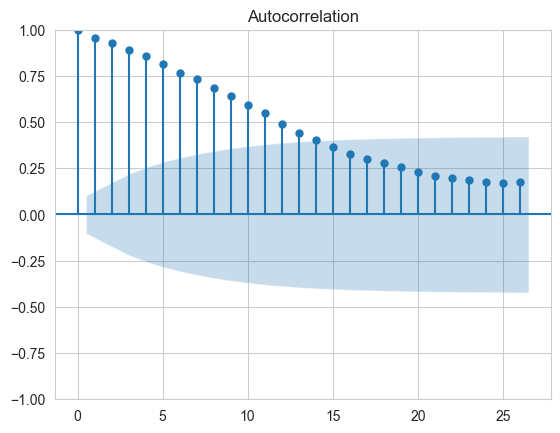

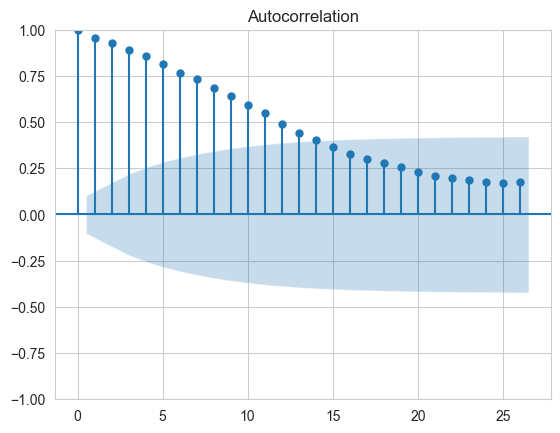

In [ ]:
# [Gráfico] ACF de serie temporal
plot_acf(semanas['total_casos'])

De acuerdo con la prueba Mann-Kendall para evaluar la tendencia monotónica en el total de casos por semana epidemiológica, la serie muestra una tendencia creciente a lo largo del tiempo, rechazando la hipótesis nula de que no sigue una tendencia. El valor de correlación de Kendall indica una moderada-fuerte relación monotónica positiva (constante creciente). La mediana del cambio por semana es aproximadamente 0.26 casos adicionales por semana. De esta manera, la prueba indica que el número de casos semanales ha aumentado significativamente de manera consistente a lo largo de los años. 

El análisis de cambio estructural (breakpoint) indica que al rededor de la semana 85 (en este caso finales del 2018) hay un cambio abrupto en la media varianza de casos. Lo mismo en la semana 165, que corresponde a una de las primeras semanas del 2020. Luego en la semana 240 (finales del 2021) se tiene otro de los cambios abruptos. El último cambio estructural es la semana 364, es decir, la primera semana del año 2023. Esta variación indica que la serie no solo tiene una tendencia creciente, sino que también existen periodos donde la dinámica cambia abruptamente, lo que indica periodos de mayor brotes o años con mayor incidencia.

De acuerdo a la función de autocorrelación ACF, la serie tiene una Autocorrelación positiva decreciente, es decir, que los valores de semanas cercanas están correlacionados, y la correlación disminuye gradualmente a medida que aumenta el lag,  esto indica que los casos dependen de semanas anteriores. La autocorrelación es significativa hasta ~15 semanas. El decaimiento gradual sugiere un una tendencia. Esto indica que para las semanas cercanas, el número de casos es cercano, reflejando la forma en que la enfermedad se propaga en el tiempo.


### **Distribución de espacial de casos**

In [ ]:
# [Test] Índice de Moran

#Unir con la geometría
muni = gdf.merge(casos, on="municipio")

# Crear matriz de pesos contiguos
w = Queen.from_dataframe(muni, use_index=False)
w.transform = "r"  #

y = muni['total_casos'].values
moran = Moran(y, w)

print("Índice de Moran:", moran.I)
print("Valor-p:", moran.p_sim)


Índice de Moran: 0.1705486844015851
Valor-p: 0.003


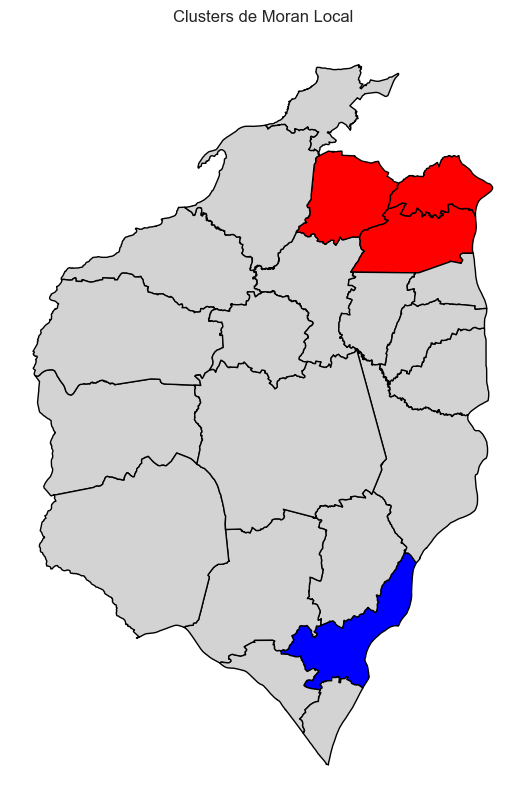

In [ ]:
# Contiguos

# Crear matriz de pesos (Queen contiguidad)
w = libpysal.weights.Queen.from_dataframe(muni, use_index=False)
w.transform = "r"
moran_loc = Moran_Local(y, w)

# Signo de Moran local: High-High, Low-Low, Low-High, High-Low
muni['HH'] = (moran_loc.q==1) & (moran_loc.p_sim < 0.05)  # High-High
muni['LL'] = (moran_loc.q==3) & (moran_loc.p_sim < 0.05)  # Low-Low
muni['HL'] = (moran_loc.q==2) & (moran_loc.p_sim < 0.05)  # High-Low
muni['LH'] = (moran_loc.q==4) & (moran_loc.p_sim < 0.05)  # Low-High

# Crear una columna con el tipo de cluster
def cluster_label(row):
    if row['HH']: return 'High-High'
    elif row['LL']: return 'Low-Low'
    elif row['HL']: return 'High-Low'
    elif row['LH']: return 'Low-High'
    else: return 'No Signif'

muni['cluster'] = muni.apply(cluster_label, axis=1)

# Definir colores
colors = {
    'High-High':'red',
    'Low-Low':'blue',
    'High-Low':'orange',
    'Low-High':'lightgreen',
    'No Signif':'lightgrey'
}

# Graficar mapa
fig, ax = plt.subplots(1, 1, figsize=(10,10))
muni.plot(color=muni['cluster'].map(colors), edgecolor='black', ax=ax)
plt.title("Clusters de Moran Local")
plt.axis('off')
plt.show()

El índice de moran indica autocorrelación positiva moderada, es decir, que en los municipios con muchos casos tienden a estar cercanos entre sí, pero no es fuerte. Con el valor-p (0.009) se puede afirmar de que los casos se agregan especialmente en algunos municipios; es decir, los municipios con más casos tienden a estar cerca unos de otros. En el mapa se identifica el cluster de mayor foco de casos en los municipios de Soledad, Malambo y Galapa. El coldspots se identifica en el municipio de Santa Lucía.